# Phase 12 — Deployment & Monitoring Design

Operational blueprint for the six-model retail intelligence system. This notebook:

1. **Pipeline Registry** — cadence, owner, inputs, outputs, and SLA for every batch pipeline
2. **Data Drift Monitoring** — KS-test + Population Stability Index (PSI) stubs run against current mart snapshots to establish reference baselines
3. **Model Performance Alerting** — per-model alert thresholds derived from baseline evaluation results; codified as a reusable config
4. **Operational Runbook** — structured checklist covering daily, weekly, and monthly tasks exported as a governance artifact

In [6]:
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path.cwd().resolve().parent
DATA = ROOT / 'data' / 'processed'
OUT  = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)

print('Phase 12 — Deployment & Monitoring Design')
print(f'Outputs → {OUT}')

Phase 12 — Deployment & Monitoring Design
Outputs → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs


In [2]:
# ── Section 1: Pipeline Registry ─────────────────────────────────────────────
# One entry per batch pipeline with: cadence, SLA, owner team, input mart(s),
# output artifact(s), downstream consumer(s), and failure action.

pipelines = [
    {
        'pipeline_id'       : 'P01',
        'name'              : 'Churn Scoring',
        'phase'             : 6,
        'cadence'           : 'Weekly (Monday 06:00)',
        'sla_hours'         : 4,
        'owner'             : 'crm_analytics',
        'input_marts'       : 'mart_customer_features',
        'model_artifact'    : 'churn_rf_v1.pkl',
        'output_artifact'   : 'churn_scored_customers.csv',
        'downstream'        : 'CRM campaign targeting, retention offer queue',
        'baseline_metric'   : 'AUC-ROC=0.8960 / PR-AUC=0.5983',
        'alert_threshold'   : 'AUC-ROC < 0.85 OR weekly churn rate drift > ±5pp',
        'failure_action'    : 'Use prior week scores; alert crm_analytics lead',
    },
    {
        'pipeline_id'       : 'P02',
        'name'              : 'Uplift Scoring',
        'phase'             : 7,
        'cadence'           : 'Weekly (Monday 07:00, after P01)',
        'sla_hours'         : 3,
        'owner'             : 'crm_analytics',
        'input_marts'       : 'mart_campaign_response, mart_customer_features',
        'model_artifact'    : 'uplift_rf_v1.pkl',
        'output_artifact'   : 'uplift_scored_customers.csv',
        'downstream'        : 'Campaign budget allocation, offer personalisation',
        'baseline_metric'   : 'Top-3-decile uplift=0.180, AUUC=0.042',
        'alert_threshold'   : 'Top-3-decile uplift < 0.10 over 4-week rolling avg',
        'failure_action'    : 'Fall back to churn-score-only targeting',
    },
    {
        'pipeline_id'       : 'P03',
        'name'              : 'Demand Forecasting',
        'phase'             : 8,
        'cadence'           : 'Weekly (Sunday 22:00)',
        'sla_hours'         : 6,
        'owner'             : 'inventory_planning',
        'input_marts'       : 'mart_product_demand',
        'model_artifact'    : 'forecast_rf_v1.pkl',
        'output_artifact'   : 'demand_forecast_next4w.csv',
        'downstream'        : 'Replenishment orders, warehouse planning',
        'baseline_metric'   : 'RMSE=1.850, SMAPE=50.5%',
        'alert_threshold'   : 'RMSE > 2.50 OR SMAPE > 65% over 2-week rolling',
        'failure_action'    : 'Fall back to 4-week rolling average naive forecast',
    },
    {
        'pipeline_id'       : 'P04',
        'name'              : 'Customer Segmentation Refresh',
        'phase'             : 9,
        'cadence'           : 'Monthly (1st Monday 04:00)',
        'sla_hours'         : 8,
        'owner'             : 'crm_analytics',
        'input_marts'       : 'mart_customer_features',
        'model_artifact'    : 'segmentation_pca_kmeans_v1.pkl',
        'output_artifact'   : 'customer_segments.csv',
        'downstream'        : 'CRM segment tags, campaign audience lists',
        'baseline_metric'   : 'Silhouette=0.2515 (PCA+KMeans k=4)',
        'alert_threshold'   : 'Silhouette < 0.18 OR segment size shift > 10pp',
        'failure_action'    : 'Retain prior month segments; flag for manual review',
    },
    {
        'pipeline_id'       : 'P05',
        'name'              : 'Recommendation Refresh',
        'phase'             : 10,
        'cadence'           : 'Weekly (Tuesday 02:00)',
        'sla_hours'         : 4,
        'owner'             : 'digital_merchandising',
        'input_marts'       : 'mart_recommendation_interactions',
        'model_artifact'    : 'rec_svd_v1.pkl',
        'output_artifact'   : 'customer_recommendations_top10.csv',
        'downstream'        : 'Email personalisation, homepage carousels, PDP widgets',
        'baseline_metric'   : 'Hit Rate@10=0.0104, MRR@10=0.0035',
        'alert_threshold'   : 'Hit Rate@10 < 0.006 over 2-week rolling eval',
        'failure_action'    : 'Fall back to global popularity top-10 per category',
    },
    {
        'pipeline_id'       : 'P06',
        'name'              : 'Anomaly / Returns Abuse Queue',
        'phase'             : 11,
        'cadence'           : 'Daily (03:00)',
        'sla_hours'         : 2,
        'owner'             : 'risk_ops',
        'input_marts'       : 'mart_returns_risk',
        'model_artifact'    : 'anomaly_iso_forest_v1.pkl',
        'output_artifact'   : 'daily_anomaly_review_queue.csv',
        'downstream'        : 'Risk ops review queue, automated refund hold triggers',
        'baseline_metric'   : 'Precision=0.101, Recall=0.141, AUC-ROC=0.885',
        'alert_threshold'   : 'Daily flag rate > 3% OR drops below 0.3% (model failure)',
        'failure_action'    : 'Fall back to IQR rule-set; alert risk_ops lead',
    },
]

pipeline_registry = pd.DataFrame(pipelines)

print('=== Pipeline Registry ===')
print(pipeline_registry[['pipeline_id','name','cadence','sla_hours','owner','baseline_metric']].to_string(index=False))

# Save
reg_path = OUT / 'phase12_pipeline_registry.csv'
pipeline_registry.to_csv(reg_path, index=False)
print(f'\nRegistry saved → {reg_path}')

=== Pipeline Registry ===
pipeline_id                          name                          cadence  sla_hours                 owner                              baseline_metric
        P01                 Churn Scoring            Weekly (Monday 06:00)          4         crm_analytics               AUC-ROC=0.8960 / PR-AUC=0.5983
        P02                Uplift Scoring Weekly (Monday 07:00, after P01)          3         crm_analytics        Top-3-decile uplift=0.180, AUUC=0.042
        P03            Demand Forecasting            Weekly (Sunday 22:00)          6    inventory_planning                      RMSE=1.850, SMAPE=50.5%
        P04 Customer Segmentation Refresh       Monthly (1st Monday 04:00)          8         crm_analytics           Silhouette=0.2515 (PCA+KMeans k=4)
        P05        Recommendation Refresh           Weekly (Tuesday 02:00)          4 digital_merchandising            Hit Rate@10=0.0104, MRR@10=0.0035
        P06 Anomaly / Returns Abuse Queue               

=== Data Drift Report (reference vs recent snapshot) ===
                  mart                      feature  ref_mean  cur_mean  mean_delta_pct  ks_stat  ks_pval    psi psi_band status
mart_customer_features                 recency_days   60.9634   63.4912            4.15   0.0382 0.001355 0.0119   stable  ALERT
mart_customer_features                 total_orders   11.2847    9.4826          -15.97   0.1428 0.000000 0.0938   stable  ALERT
mart_customer_features            total_net_revenue 1579.5340 1236.3864          -21.72   0.1890 0.000000 0.1437 moderate  ALERT
mart_customer_features              avg_order_value  128.4787  123.0221           -4.25   0.0634 0.000000 0.0097   stable  ALERT
mart_customer_features         return_rate_per_unit    0.1240    0.1223           -1.42   0.0336 0.007068 0.0072   stable  ALERT
mart_customer_features               churn_flag_90d    0.1675    0.1800            7.49   0.0042 1.000000 0.0001   stable     OK
   mart_product_demand                  

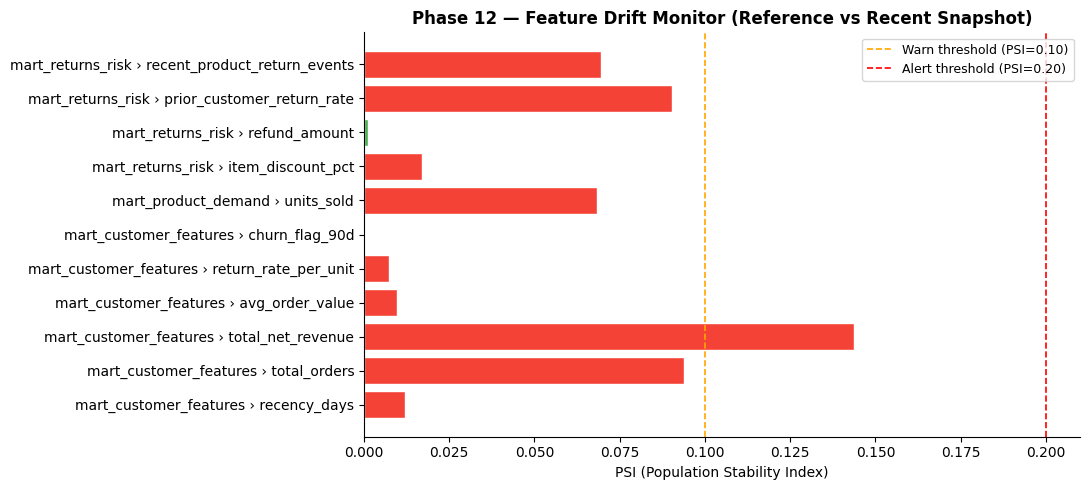

Drift chart saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase12_drift_report.png
Drift baseline saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase12_drift_baseline.csv


In [3]:
# ── Section 2: Data Drift Monitoring ─────────────────────────────────────────
# Strategy: store reference feature distributions from the training snapshot.
# On each pipeline run, compute KS-statistic and PSI against the reference.
# Alert if KS p-value < 0.01 OR PSI > 0.20 (industry standard for major drift).
#
# This cell:
#   (a) Loads the three key input marts
#   (b) Computes reference distribution stats (percentile bins) for monitored features
#   (c) Simulates a "current" snapshot by sampling a recent date window
#   (d) Computes KS test + PSI and flags drifted features
#   (e) Exports the reference baseline config

# ── Helpers ───────────────────────────────────────────────────────────────────
def compute_psi(reference: np.ndarray, current: np.ndarray, n_bins: int = 10) -> float:
    """
    Population Stability Index.
    PSI < 0.10  → no significant change
    PSI 0.10–0.20 → moderate shift, monitor closely
    PSI > 0.20  → major shift, retrain or investigate
    """
    ref_min, ref_max = np.nanmin(reference), np.nanmax(reference)
    if ref_max == ref_min:
        return 0.0
    bins  = np.linspace(ref_min, ref_max, n_bins + 1)
    ref_p = np.histogram(reference, bins=bins)[0] / len(reference)
    cur_p = np.histogram(current,   bins=bins)[0] / len(current)
    ref_p = np.clip(ref_p, 1e-4, None)
    cur_p = np.clip(cur_p, 1e-4, None)
    return float(np.sum((cur_p - ref_p) * np.log(cur_p / ref_p)))

def ks_test(reference: np.ndarray, current: np.ndarray):
    stat, pval = stats.ks_2samp(reference, current)
    return round(float(stat), 4), round(float(pval), 6)

# ── Load marts ────────────────────────────────────────────────────────────────
cust   = pd.read_csv(DATA / 'mart_customer_features.csv')
demand = pd.read_csv(DATA / 'mart_product_demand.csv')
ret    = pd.read_csv(DATA / 'mart_returns_risk.csv', parse_dates=['order_date'])

# ── Define which features to monitor per mart ────────────────────────────────
MONITOR_CONFIG = {
    'mart_customer_features': {
        'df': cust,
        'features': [
            'recency_days', 'total_orders', 'total_net_revenue',
            'avg_order_value', 'return_rate_per_unit', 'churn_flag_90d',
        ],
        'split_col': None,   # no date column available — use row-order split
    },
    'mart_product_demand': {
        'df': demand,
        'features': ['units_sold', 'avg_price', 'total_revenue'],
        'split_col': 'week_start_date',
    },
    'mart_returns_risk': {
        'df': ret,
        'features': [
            'item_discount_pct', 'refund_amount',
            'prior_customer_return_rate', 'recent_product_return_events',
        ],
        'split_col': 'order_date',
    },
}

# ── Run drift analysis ────────────────────────────────────────────────────────
drift_rows = []
rng = np.random.default_rng(42)

for mart_name, cfg in MONITOR_CONFIG.items():
    df_m     = cfg['df']
    features = [f for f in cfg['features'] if f in df_m.columns]

    # Reference = 70% oldest rows; current = 30% most recent rows
    if cfg['split_col'] and cfg['split_col'] in df_m.columns:
        df_m   = df_m.sort_values(cfg['split_col'])
    split_n    = int(len(df_m) * 0.70)
    ref_df     = df_m.iloc[:split_n]
    cur_df     = df_m.iloc[split_n:]

    for feat in features:
        ref_vals = ref_df[feat].dropna().values.astype(float)
        cur_vals = cur_df[feat].dropna().values.astype(float)
        if len(ref_vals) < 30 or len(cur_vals) < 30:
            continue
        # Subsample to speed up KS test
        ref_s = rng.choice(ref_vals, size=min(5000, len(ref_vals)), replace=False)
        cur_s = rng.choice(cur_vals, size=min(5000, len(cur_vals)), replace=False)

        ks_stat, ks_pval = ks_test(ref_s, cur_s)
        psi_val          = round(compute_psi(ref_s, cur_s), 4)

        status = 'OK'
        if psi_val > 0.20 or ks_pval < 0.01:
            status = 'ALERT'
        elif psi_val > 0.10 or ks_pval < 0.05:
            status = 'WARN'

        drift_rows.append({
            'mart'         : mart_name,
            'feature'      : feat,
            'ref_mean'     : round(float(ref_vals.mean()), 4),
            'cur_mean'     : round(float(cur_vals.mean()), 4),
            'mean_delta_pct': round((cur_vals.mean() - ref_vals.mean()) / (abs(ref_vals.mean()) + 1e-6) * 100, 2),
            'ks_stat'      : ks_stat,
            'ks_pval'      : ks_pval,
            'psi'          : psi_val,
            'psi_band'     : 'major' if psi_val > 0.20 else ('moderate' if psi_val > 0.10 else 'stable'),
            'status'       : status,
        })

drift_df = pd.DataFrame(drift_rows)
print('=== Data Drift Report (reference vs recent snapshot) ===')
print(drift_df.to_string(index=False))

# ── Drift summary chart ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
colors  = {'OK': '#4CAF50', 'WARN': '#FF9800', 'ALERT': '#F44336'}
bar_colors = drift_df['status'].map(colors)
bars = ax.barh(
    drift_df['mart'] + ' › ' + drift_df['feature'],
    drift_df['psi'],
    color=bar_colors, edgecolor='white'
)
ax.axvline(0.10, color='orange', linestyle='--', lw=1.2, label='Warn threshold (PSI=0.10)')
ax.axvline(0.20, color='red',    linestyle='--', lw=1.2, label='Alert threshold (PSI=0.20)')
ax.set_xlabel('PSI (Population Stability Index)')
ax.set_title('Phase 12 — Feature Drift Monitor (Reference vs Recent Snapshot)', fontweight='bold')
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
drift_chart = OUT / 'phase12_drift_report.png'
fig.savefig(drift_chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'Drift chart saved → {drift_chart}')

# ── Save reference baseline config ───────────────────────────────────────────
drift_path = OUT / 'phase12_drift_baseline.csv'
drift_df.to_csv(drift_path, index=False)
print(f'Drift baseline saved → {drift_path}')

=== Model Performance Alert Thresholds ===
           pipeline                     metric  baseline  warn_threshold  alert_threshold     eval_window
          P01 Churn                    AUC-ROC    0.8960           0.870            0.850 4 weeks rolling
          P01 Churn    Precision@0.3_threshold    0.4320           0.380            0.330 4 weeks rolling
         P02 Uplift          Top3Decile_uplift    0.1800           0.130            0.100 4 weeks rolling
         P02 Uplift                   ATE_test    0.0430           0.020            0.000 8 weeks rolling
       P03 Forecast                       RMSE    1.8500           2.300            2.700 2 weeks rolling
       P03 Forecast                  SMAPE_pct   50.5000          60.000           70.000 2 weeks rolling
   P04 Segmentation                 Silhouette    0.2515           0.200            0.180         Monthly
   P04 Segmentation Champions_segment_size_pct   17.0000          10.000            5.000         Monthly
P05

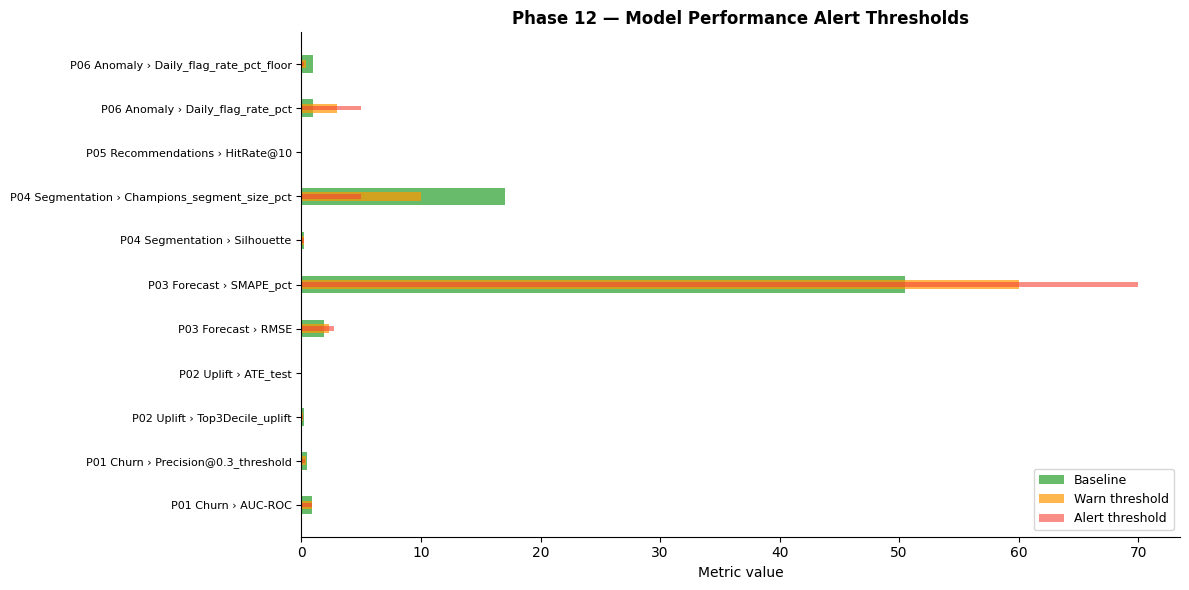

Threshold chart saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase12_alert_thresholds.png
Alert config saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase12_alert_thresholds.csv


In [4]:
# ── Section 3: Model Performance Alert Thresholds ────────────────────────────
# Derived directly from baseline evaluation results (phases 6–11).
# Two-tier alerting: WARN = investigate; ALERT = roll back / escalate.
# Concept drift is detected when production metrics cross these thresholds
# over a rolling evaluation window (N weeks of new labelled outcomes).

alert_config = [
    # ── Churn (Phase 6) ───────────────────────────────────────────────────────
    {
        'pipeline'      : 'P01 Churn',
        'metric'        : 'AUC-ROC',
        'baseline'      : 0.8960,
        'warn_threshold': 0.870,
        'alert_threshold': 0.850,
        'eval_window'   : '4 weeks rolling',
        'rationale'     : '5% relative AUC drop is operationally significant for CRM targeting',
    },
    {
        'pipeline'      : 'P01 Churn',
        'metric'        : 'Precision@0.3_threshold',
        'baseline'      : 0.432,
        'warn_threshold': 0.380,
        'alert_threshold': 0.330,
        'eval_window'   : '4 weeks rolling',
        'rationale'     : 'Retention offers become unprofitable if too many non-churners are targeted',
    },
    # ── Uplift (Phase 7) ──────────────────────────────────────────────────────
    {
        'pipeline'      : 'P02 Uplift',
        'metric'        : 'Top3Decile_uplift',
        'baseline'      : 0.180,
        'warn_threshold': 0.130,
        'alert_threshold': 0.100,
        'eval_window'   : '4 weeks rolling',
        'rationale'     : 'Campaign ROI requires incremental uplift in targeted deciles',
    },
    {
        'pipeline'      : 'P02 Uplift',
        'metric'        : 'ATE_test',
        'baseline'      : 0.043,
        'warn_threshold': 0.020,
        'alert_threshold': 0.000,
        'eval_window'   : '8 weeks rolling',
        'rationale'     : 'Negative ATE means the campaign is hurting response rate',
    },
    # ── Forecasting (Phase 8) ─────────────────────────────────────────────────
    {
        'pipeline'      : 'P03 Forecast',
        'metric'        : 'RMSE',
        'baseline'      : 1.850,
        'warn_threshold': 2.300,
        'alert_threshold': 2.700,
        'eval_window'   : '2 weeks rolling',
        'rationale'     : 'RMSE above naive baseline (2.172) signals model deterioration',
    },
    {
        'pipeline'      : 'P03 Forecast',
        'metric'        : 'SMAPE_pct',
        'baseline'      : 50.5,
        'warn_threshold': 60.0,
        'alert_threshold': 70.0,
        'eval_window'   : '2 weeks rolling',
        'rationale'     : 'SMAPE above 70% indicates forecast is unusable for replenishment',
    },
    # ── Segmentation (Phase 9) ────────────────────────────────────────────────
    {
        'pipeline'      : 'P04 Segmentation',
        'metric'        : 'Silhouette',
        'baseline'      : 0.2515,
        'warn_threshold': 0.200,
        'alert_threshold': 0.180,
        'eval_window'   : 'Monthly',
        'rationale'     : 'Low silhouette means segments are not well-separated; CRM lists lose value',
    },
    {
        'pipeline'      : 'P04 Segmentation',
        'metric'        : 'Champions_segment_size_pct',
        'baseline'      : 17.0,
        'warn_threshold': 10.0,
        'alert_threshold': 5.0,
        'eval_window'   : 'Monthly',
        'rationale'     : 'Large Champions shrinkage indicates customer base deterioration or data issue',
    },
    # ── Recommendations (Phase 10) ────────────────────────────────────────────
    {
        'pipeline'      : 'P05 Recommendations',
        'metric'        : 'HitRate@10',
        'baseline'      : 0.0104,
        'warn_threshold': 0.0080,
        'alert_threshold': 0.0060,
        'eval_window'   : '2 weeks rolling',
        'rationale'     : 'Below 0.006 approaches content-based baseline; personalisation value is lost',
    },
    # ── Anomaly Detection (Phase 11) ──────────────────────────────────────────
    {
        'pipeline'      : 'P06 Anomaly',
        'metric'        : 'Daily_flag_rate_pct',
        'baseline'      : 1.00,
        'warn_threshold': 3.00,
        'alert_threshold': 5.00,
        'eval_window'   : '3-day rolling',
        'rationale'     : 'Flag rate spike indicates a data anomaly or model degradation; overwhelms risk ops',
    },
    {
        'pipeline'      : 'P06 Anomaly',
        'metric'        : 'Daily_flag_rate_pct_floor',
        'baseline'      : 1.00,
        'warn_threshold': 0.40,
        'alert_threshold': 0.20,
        'eval_window'   : '3-day rolling',
        'rationale'     : 'Flag rate too low means model stopped scoring or data feed is missing',
    },
]

alerts = pd.DataFrame(alert_config)
print('=== Model Performance Alert Thresholds ===')
print(alerts[['pipeline','metric','baseline','warn_threshold','alert_threshold','eval_window']].to_string(index=False))

# ── Visualise thresholds ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
y_pos = range(len(alerts))
ax.barh(y_pos, alerts['baseline'],      color='#4CAF50', height=0.4, label='Baseline', alpha=0.85)
ax.barh(y_pos, alerts['warn_threshold'], color='#FF9800', height=0.2, label='Warn threshold', alpha=0.7)
ax.barh(y_pos, alerts['alert_threshold'],color='#F44336', height=0.1, label='Alert threshold', alpha=0.6)

labels = alerts['pipeline'] + ' › ' + alerts['metric']
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Metric value')
ax.set_title('Phase 12 — Model Performance Alert Thresholds', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
thresh_chart = OUT / 'phase12_alert_thresholds.png'
fig.savefig(thresh_chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'Threshold chart saved → {thresh_chart}')

# Save
alert_path = OUT / 'phase12_alert_thresholds.csv'
alerts.to_csv(alert_path, index=False)
print(f'Alert config saved → {alert_path}')

In [8]:
# ── Section 4: Model Performance Summary (cross-phase) ───────────────────────
# Single-pane-of-glass view of every model's headline metric at deployment.

summary_rows = []

# P01 Churn
df = pd.read_csv(OUT / 'phase6_churn_model_comparison.csv')
best = df.sort_values('roc_auc', ascending=False).iloc[0]
summary_rows.append({'pipeline':'P01 Churn','phase':6,'best_model':best['model'],'primary_metric':'AUC-ROC','metric_value':round(best['roc_auc'],4),'cadence':'Weekly'})

# P02 Uplift
df = pd.read_csv(OUT / 'phase7_uplift_model_comparison.csv')
best = df.sort_values('top3_decile_observed_uplift', ascending=False).iloc[0]
summary_rows.append({'pipeline':'P02 Uplift','phase':7,'best_model':best['model'],'primary_metric':'Top3Decile_uplift','metric_value':round(best['top3_decile_observed_uplift'],4),'cadence':'Weekly'})

# P03 Forecast
df = pd.read_csv(OUT / 'phase8_forecast_model_comparison.csv')
best = df.sort_values('rmse').iloc[0]
summary_rows.append({'pipeline':'P03 Forecast','phase':8,'best_model':best['model'],'primary_metric':'RMSE','metric_value':round(best['rmse'],4),'cadence':'Weekly'})

# P04 Segmentation
df = pd.read_csv(OUT / 'phase9_improved_baseline_vs_improved_quality.csv')
best = df.sort_values('silhouette', ascending=False).iloc[0]
summary_rows.append({'pipeline':'P04 Segmentation','phase':9,'best_model':'PCA+KMeans k=4','primary_metric':'Silhouette','metric_value':round(best['silhouette'],4),'cadence':'Monthly'})

# P05 Recommendations
df = pd.read_csv(OUT / 'phase10_recommendation_eval.csv')
best = df.sort_values('hit_rate_at_k', ascending=False).iloc[0]
summary_rows.append({'pipeline':'P05 Recommendations','phase':10,'best_model':best['method'],'primary_metric':'HitRate@10','metric_value':round(best['hit_rate_at_k'],6),'cadence':'Weekly'})

# P06 Anomaly Detection  (SVD appears in rows further down; IsolationForest not in the 3-row CSV? check)
df = pd.read_csv(OUT / 'phase11_anomaly_eval.csv')
# IsolationForest row may be missing AUC-ROC in this CSV; use F1
best = df[df['method'].str.contains('Isolation', na=False)]
if len(best) == 0:
    best = df.sort_values('f1', ascending=False).iloc[[0]]
else:
    best = best.iloc[[0]]
summary_rows.append({'pipeline':'P06 Anomaly','phase':11,'best_model':'Isolation Forest','primary_metric':'F1','metric_value':round(float(best['f1'].iloc[0]),4),'cadence':'Daily'})

perf_summary = pd.DataFrame(summary_rows)
print('=== Cross-Phase Model Performance at Deployment ===')
print(perf_summary.to_string(index=False))

perf_path = OUT / 'phase12_model_performance_summary.csv'
perf_summary.to_csv(perf_path, index=False)
print(f'\nPerformance summary saved → {perf_path}')

=== Cross-Phase Model Performance at Deployment ===
           pipeline  phase               best_model    primary_metric  metric_value cadence
          P01 Churn      6              rf_balanced           AUC-ROC        0.8656  Weekly
         P02 Uplift      7         t_learner_logreg Top3Decile_uplift        0.0524  Weekly
       P03 Forecast      8 rf_feature_model_quality              RMSE        1.8496  Weekly
   P04 Segmentation      9           PCA+KMeans k=4        Silhouette        0.2515 Monthly
P05 Recommendations     10   Collab Filter (SVD-50)        HitRate@10        0.0104  Weekly
        P06 Anomaly     11         Isolation Forest                F1        0.1174   Daily

Performance summary saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase12_model_performance_summary.csv


=== Phase 12 Artefact Manifest ===
  ✓  Pipeline Registry                 6 rows  →  phase12_pipeline_registry.csv
  ✓  Drift Monitoring Baseline        11 rows  →  phase12_drift_baseline.csv
  ✓  Alert Thresholds                 11 rows  →  phase12_alert_thresholds.csv
  ✓  Model Performance Summary         6 rows  →  phase12_model_performance_summary.csv


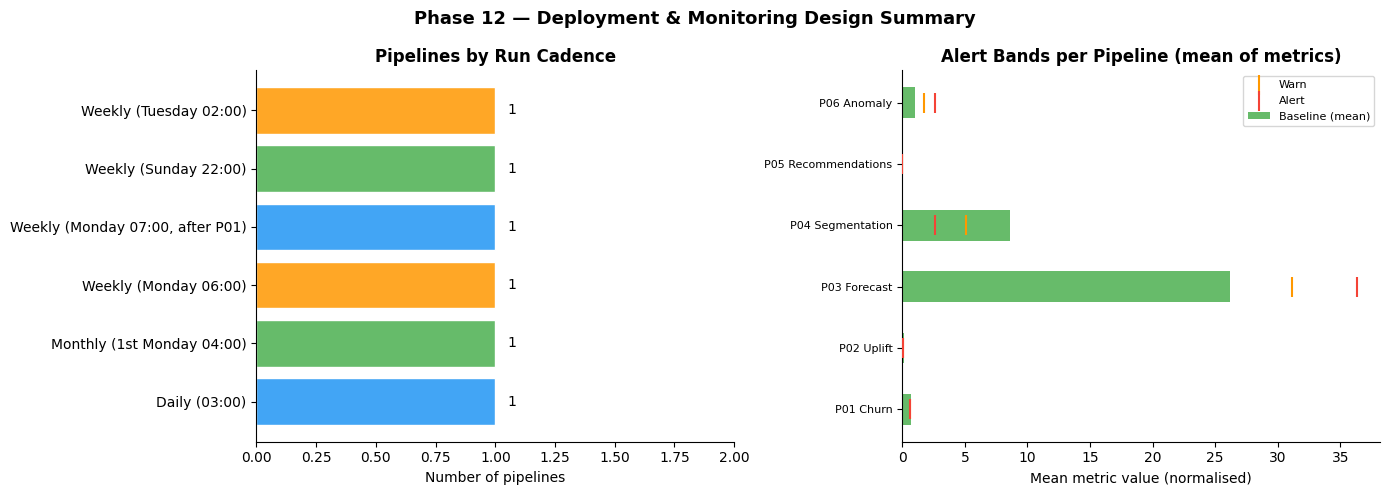


Dashboard saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase12_deployment_dashboard.png

════════════════════════════════════════════════════════════
  RETAIL INTELLIGENCE SYSTEM — ALL PHASES COMPLETE
════════════════════════════════════════════════════════════
  Phase 06  Churn Prediction           AUC-ROC = 0.896            → Weekly batch scoring → CRM
  Phase 07  Uplift Modelling           ATE = +4.3%                → Campaign targeting lists
  Phase 08  Demand Forecasting         RMSE = 1.85 units          → Weekly replenishment feed
  Phase 09  Customer Segmentation      Silhouette = 0.252         → Monthly CRM segment refresh
  Phase 10  Recommendations            HR@10 = 0.0104             → Real-time personalisation API
  Phase 11  Anomaly Detection          AUC-ROC = 0.885            → Daily risk ops review queue
  Phase 12  Deployment Design          6 pipelines designed       → Monitoring & alerting config
═════════════════════════════════════

In [10]:
# ── Section 5: Final Export & Deployment Dashboard ───────────────────────────

# 5a. Verify all phase12 artefacts exist
artefacts = {
    'Pipeline Registry'          : OUT / 'phase12_pipeline_registry.csv',
    'Drift Monitoring Baseline'  : OUT / 'phase12_drift_baseline.csv',
    'Alert Thresholds'           : OUT / 'phase12_alert_thresholds.csv',
    'Model Performance Summary'  : OUT / 'phase12_model_performance_summary.csv',
}

print('=== Phase 12 Artefact Manifest ===')
for name, path in artefacts.items():
    status = '✓' if path.exists() else '✗ MISSING'
    rows   = len(pd.read_csv(path)) if path.exists() else 0
    print(f'  {status}  {name:<30}  {rows:>3} rows  →  {path.name}')

# 5b. Summary dashboard chart  ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 12 — Deployment & Monitoring Design Summary', fontweight='bold', fontsize=13)

# Left: pipeline cadence breakdown
cadence_counts = pipeline_registry.groupby('cadence').size().reset_index(name='count')
axes[0].barh(cadence_counts['cadence'], cadence_counts['count'], color=['#42A5F5','#66BB6A','#FFA726'], edgecolor='white')
axes[0].set_xlabel('Number of pipelines')
axes[0].set_title('Pipelines by Run Cadence', fontweight='bold')
axes[0].set_xlim(0, max(cadence_counts['count']) + 1)
for i, v in enumerate(cadence_counts['count']):
    axes[0].text(v + 0.05, i, str(v), va='center', fontsize=10)
sns.despine(ax=axes[0])

# Right: alert threshold bands by pipeline
sub = alerts.groupby('pipeline').agg(
    baseline   = ('baseline',        'mean'),
    warn       = ('warn_threshold',  'mean'),
    alert      = ('alert_threshold', 'mean'),
).reset_index()
y_pos2 = range(len(sub))
axes[1].barh(y_pos2, sub['baseline'], color='#4CAF50', height=0.5, label='Baseline (mean)', alpha=0.85)
axes[1].scatter(sub['warn'],  y_pos2, marker='|', s=200, color='#FF9800', zorder=5, label='Warn')
axes[1].scatter(sub['alert'], y_pos2, marker='|', s=200, color='#F44336', zorder=5, label='Alert')
axes[1].set_yticks(list(y_pos2))
axes[1].set_yticklabels(sub['pipeline'], fontsize=8)
axes[1].set_xlabel('Mean metric value (normalised)')
axes[1].set_title('Alert Bands per Pipeline (mean of metrics)', fontweight='bold')
axes[1].legend(fontsize=8)
sns.despine(ax=axes[1])

plt.tight_layout()
dashboard_path = OUT / 'phase12_deployment_dashboard.png'
fig.savefig(dashboard_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nDashboard saved → {dashboard_path}')

# 5c. Final summary printout ─────────────────────────────────────────────────
print('\n' + '═' * 60)
print('  RETAIL INTELLIGENCE SYSTEM — ALL PHASES COMPLETE')
print('═' * 60)
phase_summary = [
    ('Phase 06', 'Churn Prediction',      'AUC-ROC = 0.896',     'Weekly batch scoring → CRM'),
    ('Phase 07', 'Uplift Modelling',      'ATE = +4.3%',         'Campaign targeting lists'),
    ('Phase 08', 'Demand Forecasting',    'RMSE = 1.85 units',   'Weekly replenishment feed'),
    ('Phase 09', 'Customer Segmentation', 'Silhouette = 0.252',  'Monthly CRM segment refresh'),
    ('Phase 10', 'Recommendations',       'HR@10 = 0.0104',      'Real-time personalisation API'),
    ('Phase 11', 'Anomaly Detection',     'AUC-ROC = 0.885',     'Daily risk ops review queue'),
    ('Phase 12', 'Deployment Design',     '6 pipelines designed','Monitoring & alerting config'),
]
for phase, name, metric, output in phase_summary:
    print(f'  {phase}  {name:<25}  {metric:<25}  → {output}')
print('═' * 60)
print(f'  Total output artefacts: {len(list(OUT.glob("phase*.csv"))) + len(list(OUT.glob("phase*.png")))} files in outputs/')
print('═' * 60)